In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Дата          301355 non-null  datetime64[ns]
 1   Склад         301355 non-null  int64         
 2   Контрагент    301355 non-null  object        
 3   Номенклатура  301355 non-null  object        
 4   Количество    301355 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 11.5+ MB


Сразу переведем столбец "Дата" в правильный формат

In [9]:
df['Дата'] = pd.to_datetime(df['Дата'])

In [10]:
df['Дата'].dtype

dtype('<M8[ns]')

Сгруппируйте данные по дате, посчитайте количество продаж

In [15]:
grouped_df = df.groupby('Дата').size().reset_index(name='Количество_продаж')

Вывести несколько первых строк сгруппированных данных

In [16]:
grouped_df.head()

,Дата,Количество_продаж
0,2018-01-04,1840
1,2018-01-05,1301
2,2018-01-06,1306
3,2018-01-07,1322
4,2018-01-09,1719


Нарисуйте график продаж у `grouped_df`

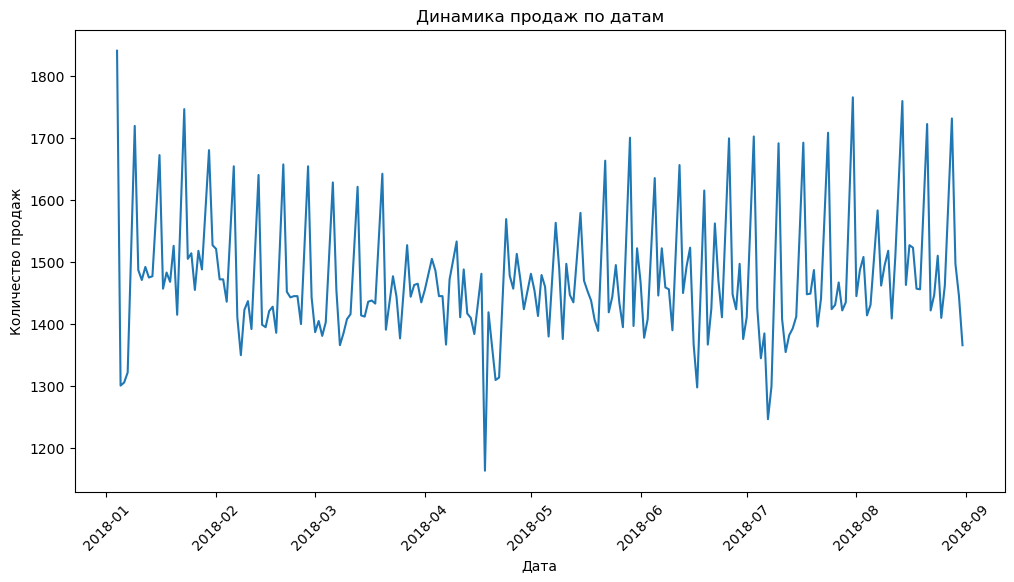

In [20]:
plt.figure(figsize=(12,6))
plt.plot(grouped_df['Дата'], grouped_df['Количество_продаж'])
plt.title('Динамика продаж по датам')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.xticks(rotation=45)
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [ ]:
-- На графике показана динамика количества продаж по датам за рассматриваемый период.
-- По графику заметно, что количество продаж является не стабильным и постоянно колеблется.
-- Основная часть значений находится примерно в диапазоне от 1350 до 1600 продаж в день.
-- Также наблюдаются резкие просадки, например до уровня около 1150–1300 продаж,
что может указывать на снижение активности покупателей, выходные дни или внешние факторы.
-- Явного устойчивого тренда на постоянный рост или снижение не наблюдается, однако во второй половине периода пики продаж встречаются чаще.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [23]:
df[df['Количество'] == df['Количество'].max()]

,Дата,Склад,Контрагент,Номенклатура,Количество
218822,2018-06-28,1,address_208,product_0,200


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [28]:
df['День_недели'] = df['Дата'].dt.day_name()
filtered_df = df[
    (df['Склад'] == 3) &
    (df['Дата'].dt.month.isin([6, 7, 8])) &
    (df['День_недели'] == 'Wednesday')
]
filtered_df.head()

,Дата,Склад,Контрагент,Номенклатура,Количество,День_недели
191165,2018-06-06,3,address_206,product_0,2,Wednesday
191166,2018-06-06,3,address_206,product_1,4,Wednesday
191167,2018-06-06,3,address_206,product_2,4,Wednesday
191168,2018-06-06,3,address_206,product_3,2,Wednesday
191169,2018-06-06,3,address_206,product_4,1,Wednesday


In [29]:
top_products = filtered_df.groupby('Номенклатура')['Количество'].sum().reset_index()
top_products.sort_values(by='Количество', ascending=False).head()

,Номенклатура,Количество
1,product_1,2267
12,product_2,2060
0,product_0,1324
17,product_3,914
20,product_6,650


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [49]:
weather = pd.read_csv(
    'weather_astana.csv',
    sep=';',
    skiprows=6,
    encoding='utf-8'
)


In [50]:
weather.head()

,Местное время в Астане,T,Po,P,Pa,U,DD,Ff,ff10,ff3,...,Cm,Ch,VV,Td,RRR,tR,E,Tg,E',sss
31.08.2018 23:00,8.2,736.6,768.3,0.2,78.0,"Ветер, дующий с северо-востока",4,NaN,NaN,70 – 80%.,...,"Перистых, перисто-кучевых или перисто-слоистых...",NaN,4.6,Следы осадков,12.0,NaN,NaN,NaN,NaN,NaN
31.08.2018 20:00,9.6,736.4,767.9,1.2,88.0,"Ветер, дующий с западо-северо-запада",3,NaN,NaN,"90 или более, но не 100%",...,"Перистых, перисто-кучевых или перисто-слоистых...",NaN,7.7,Следы осадков,12.0,NaN,NaN,NaN,NaN,NaN
31.08.2018 17:00,11.3,735.2,766.4,0.4,83.0,"Ветер, дующий с востоко-северо-востока",4,NaN,NaN,100%.,...,NaN,10.0,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31.08.2018 14:00,12.3,734.8,765.9,0.9,80.0,"Ветер, дующий с северо-востока",4,NaN,NaN,100%.,...,NaN,4.0,8.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31.08.2018 11:00,13.2,733.9,764.8,1.0,83.0,"Ветер, дующий с северо-северо-востока",4,NaN,NaN,100%.,...,NaN,10.0,10.3,3.0,12.0,NaN,NaN,NaN,NaN,NaN


In [51]:
weather = weather.reset_index()
weather = weather.rename(columns={'index': 'Дата'})
weather = weather.rename(columns={'Местное время в Астане': 't'})

In [52]:
weather.head()

,Дата,t,T,Po,P,Pa,U,DD,Ff,ff10,...,Cm,Ch,VV,Td,RRR,tR,E,Tg,E',sss
0,31.08.2018 23:00,8.2,736.6,768.3,0.2,78.0,"Ветер, дующий с северо-востока",4,NaN,NaN,...,"Перистых, перисто-кучевых или перисто-слоистых...",NaN,4.6,Следы осадков,12.0,NaN,NaN,NaN,NaN,NaN
1,31.08.2018 20:00,9.6,736.4,767.9,1.2,88.0,"Ветер, дующий с западо-северо-запада",3,NaN,NaN,...,"Перистых, перисто-кучевых или перисто-слоистых...",NaN,7.7,Следы осадков,12.0,NaN,NaN,NaN,NaN,NaN
2,31.08.2018 17:00,11.3,735.2,766.4,0.4,83.0,"Ветер, дующий с востоко-северо-востока",4,NaN,NaN,...,NaN,10.0,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,31.08.2018 14:00,12.3,734.8,765.9,0.9,80.0,"Ветер, дующий с северо-востока",4,NaN,NaN,...,NaN,4.0,8.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,31.08.2018 11:00,13.2,733.9,764.8,1.0,83.0,"Ветер, дующий с северо-северо-востока",4,NaN,NaN,...,NaN,10.0,10.3,3.0,12.0,NaN,NaN,NaN,NaN,NaN


In [53]:
weather['Дата'] = pd.to_datetime(weather['Дата'].str.split().str[0], dayfirst=True)

In [54]:
weather.head()

,Дата,t,T,Po,P,Pa,U,DD,Ff,ff10,...,Cm,Ch,VV,Td,RRR,tR,E,Tg,E',sss
0,2018-08-31,8.2,736.6,768.3,0.2,78.0,"Ветер, дующий с северо-востока",4,NaN,NaN,...,"Перистых, перисто-кучевых или перисто-слоистых...",NaN,4.6,Следы осадков,12.0,NaN,NaN,NaN,NaN,NaN
1,2018-08-31,9.6,736.4,767.9,1.2,88.0,"Ветер, дующий с западо-северо-запада",3,NaN,NaN,...,"Перистых, перисто-кучевых или перисто-слоистых...",NaN,7.7,Следы осадков,12.0,NaN,NaN,NaN,NaN,NaN
2,2018-08-31,11.3,735.2,766.4,0.4,83.0,"Ветер, дующий с востоко-северо-востока",4,NaN,NaN,...,NaN,10.0,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2018-08-31,12.3,734.8,765.9,0.9,80.0,"Ветер, дующий с северо-востока",4,NaN,NaN,...,NaN,4.0,8.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2018-08-31,13.2,733.9,764.8,1.0,83.0,"Ветер, дующий с северо-северо-востока",4,NaN,NaN,...,NaN,10.0,10.3,3.0,12.0,NaN,NaN,NaN,NaN,NaN


In [55]:
weather_daily = weather.groupby('Дата')['t'].mean().reset_index()
weather_daily.head()

,Дата,t
0,2018-01-04,-14.0750
1,2018-01-05,-16.8625
2,2018-01-06,-13.3000
3,2018-01-07,-12.7500
4,2018-01-08,-15.4125


In [56]:
merged_df = pd.merge(grouped_df, weather_daily, on='Дата', how='inner')
merged_df.head()

,Дата,Количество_продаж,MA7,t
0,2018-01-04,1840,NaN,-14.0750
1,2018-01-05,1301,NaN,-16.8625
2,2018-01-06,1306,NaN,-13.3000
3,2018-01-07,1322,NaN,-12.7500
4,2018-01-09,1719,NaN,-6.2500


In [57]:
merged_df = merged_df.drop(columns='MA7')
merged_df.head()

,Дата,Количество_продаж,t
0,2018-01-04,1840,-14.0750
1,2018-01-05,1301,-16.8625
2,2018-01-06,1306,-13.3000
3,2018-01-07,1322,-12.7500
4,2018-01-09,1719,-6.2500


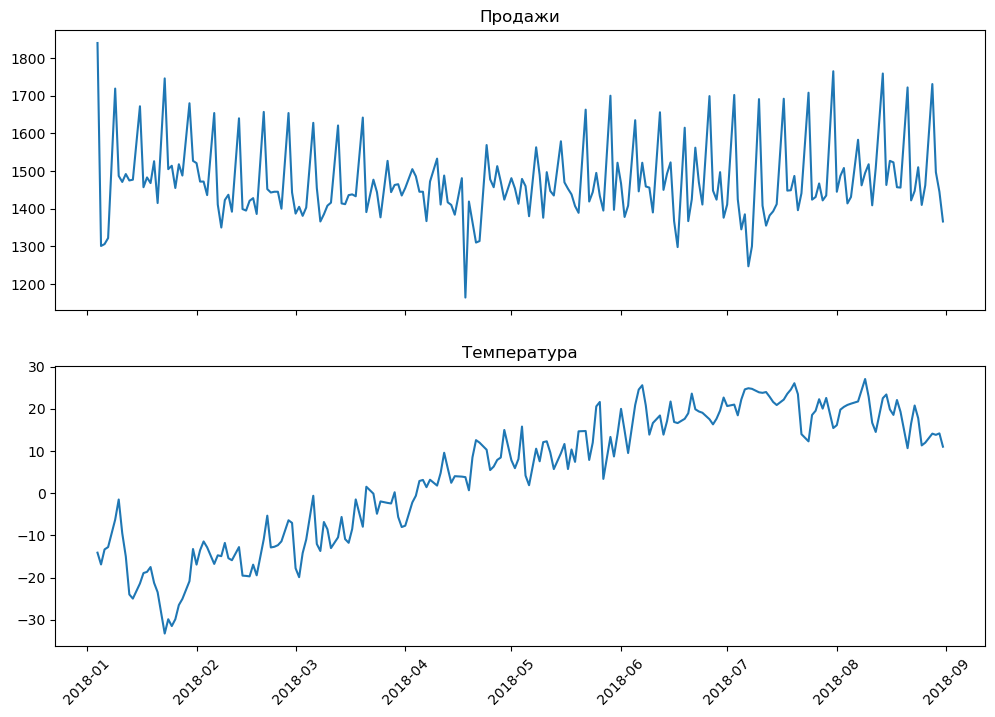

In [62]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8), sharex=True)

ax1.plot(merged_df['Дата'], merged_df['Количество_продаж'])
ax1.set_title('Продажи')

ax2.plot(merged_df['Дата'], merged_df['t'])
ax2.set_title('Температура')

plt.xticks(rotation=45)
plt.show()